# Análise Exploratória dos dados

In [241]:
%%capture
!pip install xgboost catboost scikit-learn matplotlib seaborn pandas numpy

In [242]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import os, unicodedata, re
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [243]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [244]:
exclude_resistence_columns = {"Autores/ano","ID_Mistura"}

In [245]:
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto'
file_path = os.path.join(base_dir, 'BD_filerCalcario_versao_1.xlsx')
file = pd.ExcelFile(file_path)
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
print(file.sheet_names)

['BD_ML_Resis', 'BD_ML_Slump', 'Dicionario_Variaveis']


In [246]:
df_resistencia = file.parse('BD_ML_Resis')
df_resistencia.drop(inplace=True, columns=exclude_resistence_columns)
df_resistencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Cimento_kg_m3                599 non-null    float64
 1   Filer_Calcario_kg_m3         599 non-null    float64
 2   Agua_kg_m3                   599 non-null    float64
 3   Agregado_Miudo_Total_kg_m3   599 non-null    float64
 4   Agregado_Graudo_Total_kg_m3  599 non-null    float64
 5   Superplastificante_kg_m3     554 non-null    float64
 6   Relacao_Agua_Cimento         599 non-null    float64
 7   idade                        599 non-null    int64  
 8   ln_Idade                     599 non-null    float64
 9   Tipo_Molde_Cod               599 non-null    int64  
 10  Metodo_Emp_Cod               599 non-null    int64  
 11  Usa_SP                       599 non-null    int64  
 12  Classe_Cim_OpA               599 non-null    int64  
 13  Relacao_Agua_Aglomer

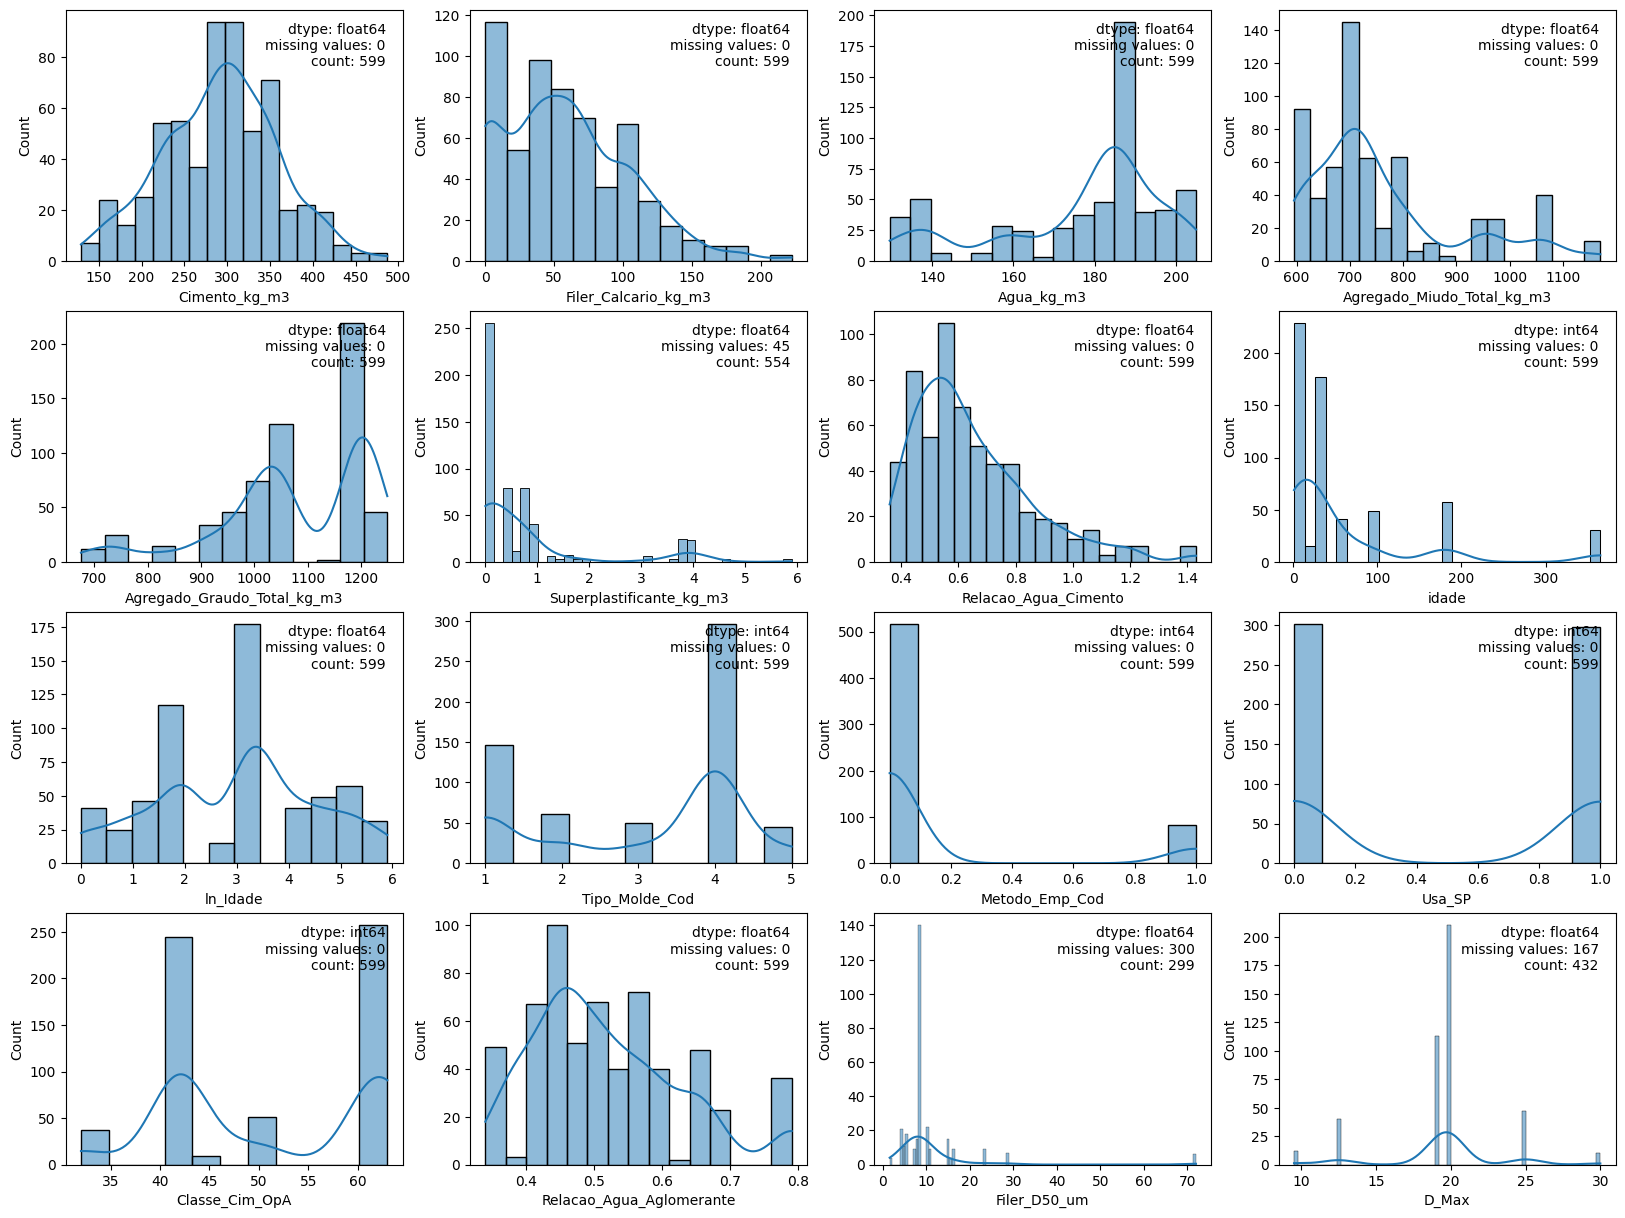

In [247]:
columns = df_resistencia.columns
figure, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))

for i, column in enumerate(columns):
    row = i // 4
    col = i % 4
    if column == 'Resistencia_Compressao_MPa':
        continue
    text = (f"dtype: {df_resistencia[column].dtype}\n"
            f"missing values: {df_resistencia[column].isnull().sum()}\n"
            f"count: {df_resistencia[column].count()}")
    axes[row][col].text(0.95, 0.95, text, transform=axes[row][col].transAxes,
                        verticalalignment='top', horizontalalignment='right')
    sns.histplot(df_resistencia[column], ax=axes[row][col], kde=True)

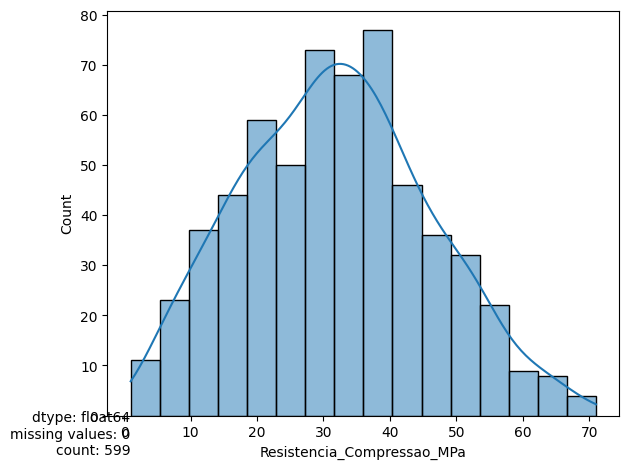

In [248]:
text = (f"dtype: {df_resistencia['Resistencia_Compressao_MPa'].dtype}\n"
            f"missing values: {df_resistencia['Resistencia_Compressao_MPa'].isnull().sum()}\n"
            f"count: {df_resistencia['Resistencia_Compressao_MPa'].count()}")
plt.text(0.95, 0.95, text, verticalalignment='top', horizontalalignment='right')
sns.histplot(df_resistencia['Resistencia_Compressao_MPa'], kde=True)
plt.tight_layout()
plt.show()

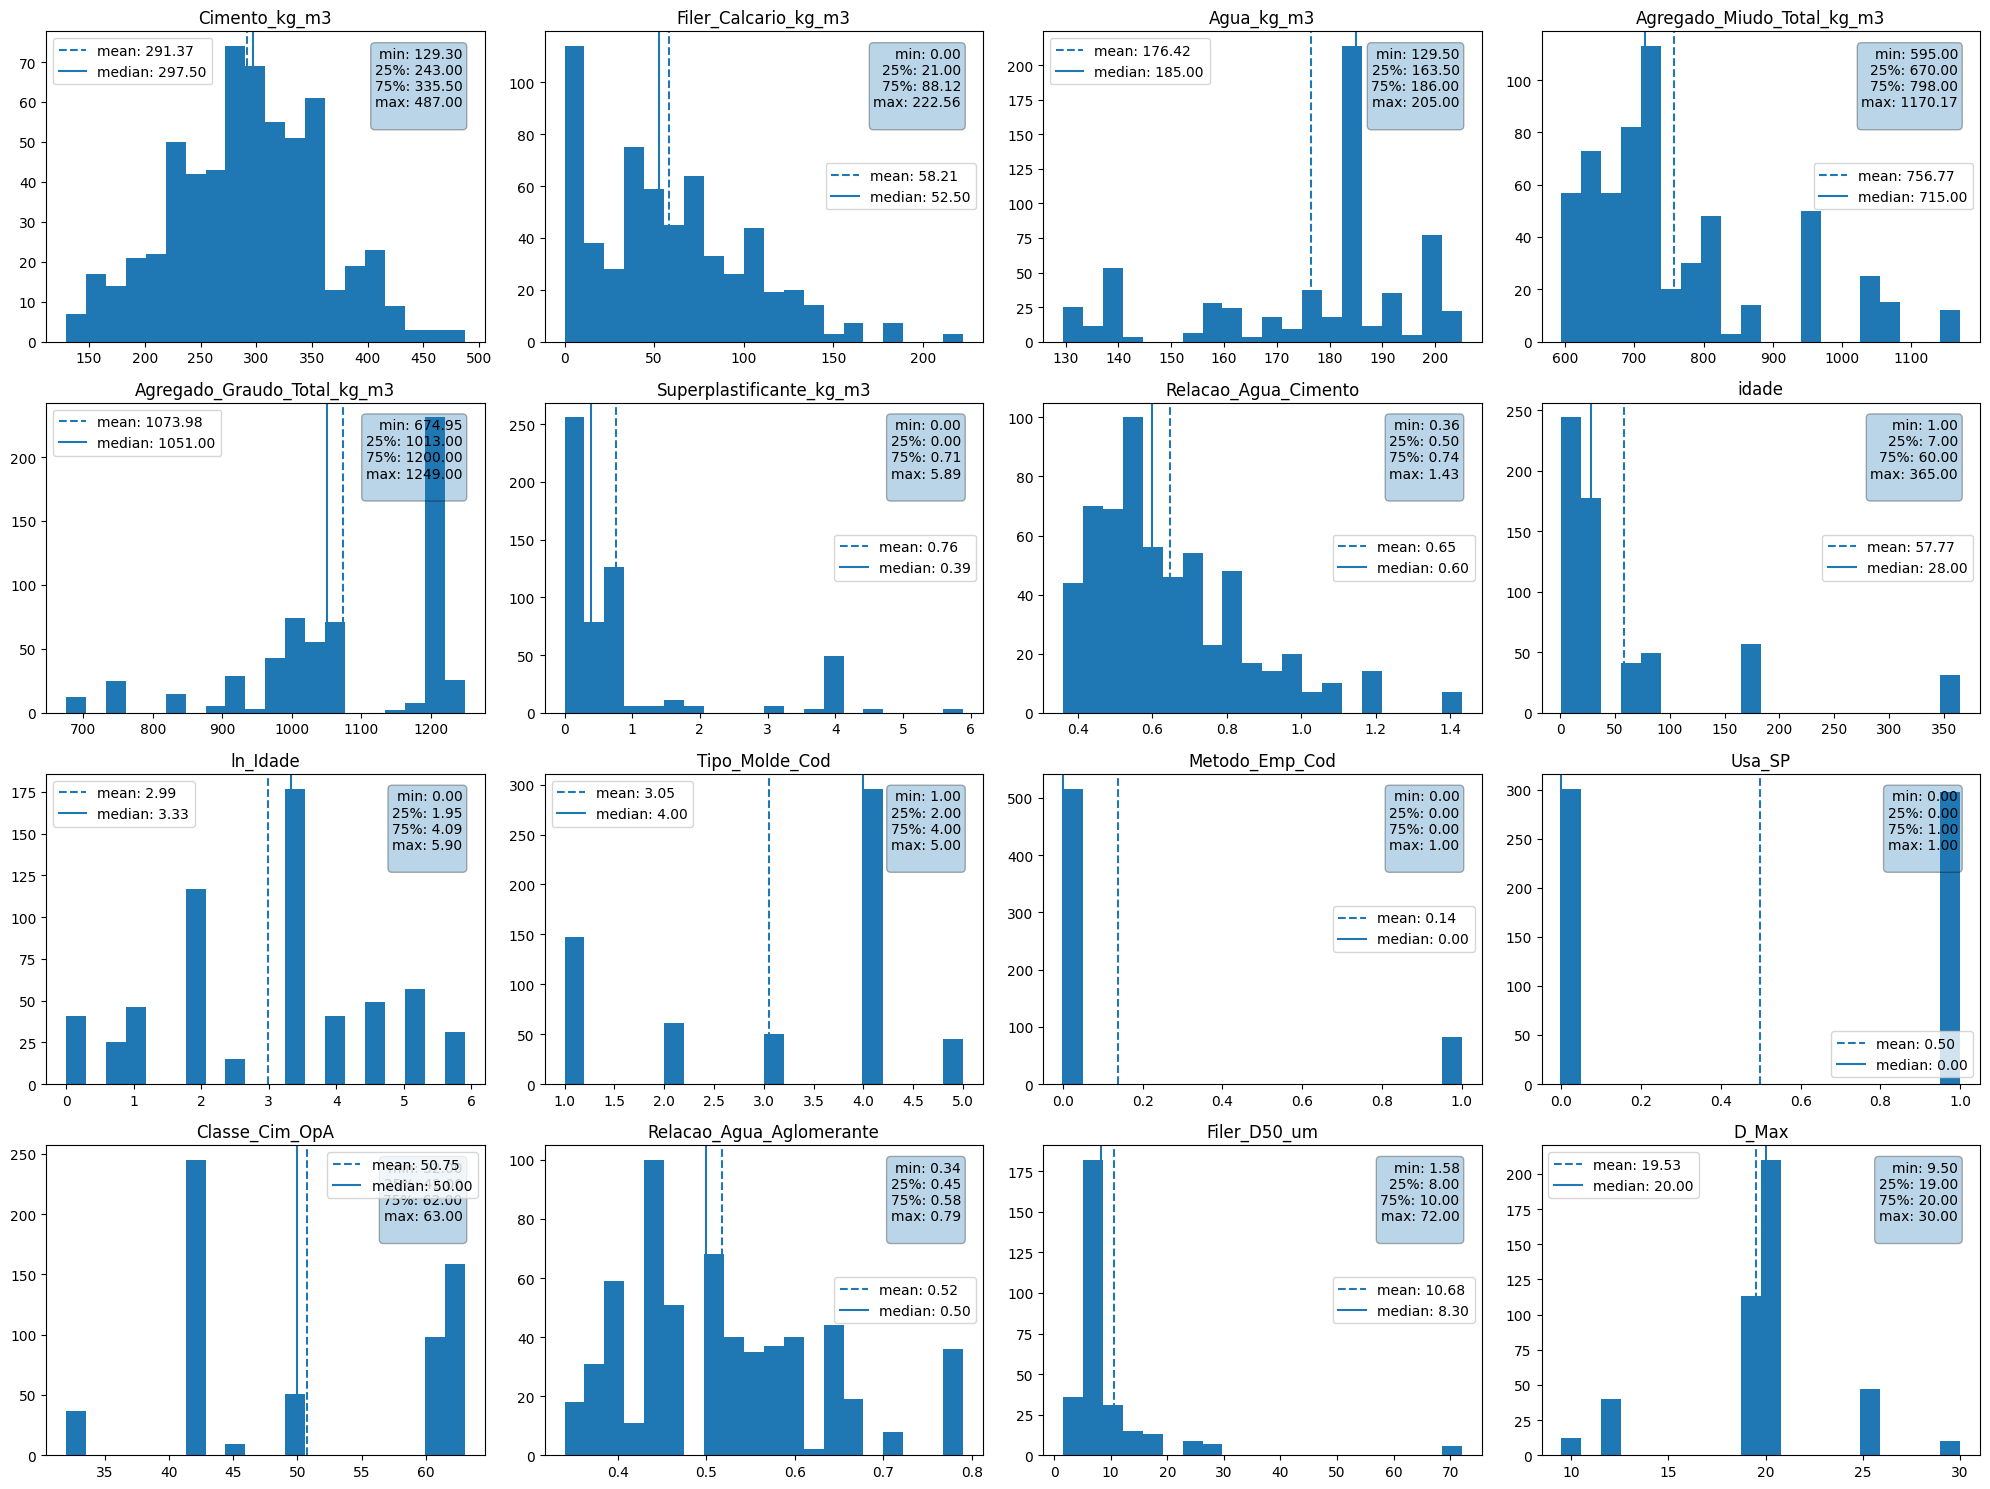

In [249]:
figure, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))

for i, column in enumerate(columns):
    if i == len(columns) - 1:
        continue
    ax = axes[i // 4, i % 4]
    data = df_resistencia[column]

    ax.set_title(column)
    ax.hist(data, bins=20)
    
    stats = data.describe()
    
    # Linhas de referência
    ax.axvline(stats['mean'], linestyle='--', label=f"mean: {stats['mean']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"median: {stats['50%']:.2f}")
    
    # Texto com resumo
    text = (
        f"min: {stats['min']:.2f}\n"
        f"25%: {stats['25%']:.2f}\n"
        f"75%: {stats['75%']:.2f}\n"
        f"max: {stats['max']:.2f}\n"
    )
    
    ax.text(
        0.95, 0.95, text,
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle="round", alpha=0.3)
    )
    
    ax.legend()

plt.tight_layout()
plt.show()

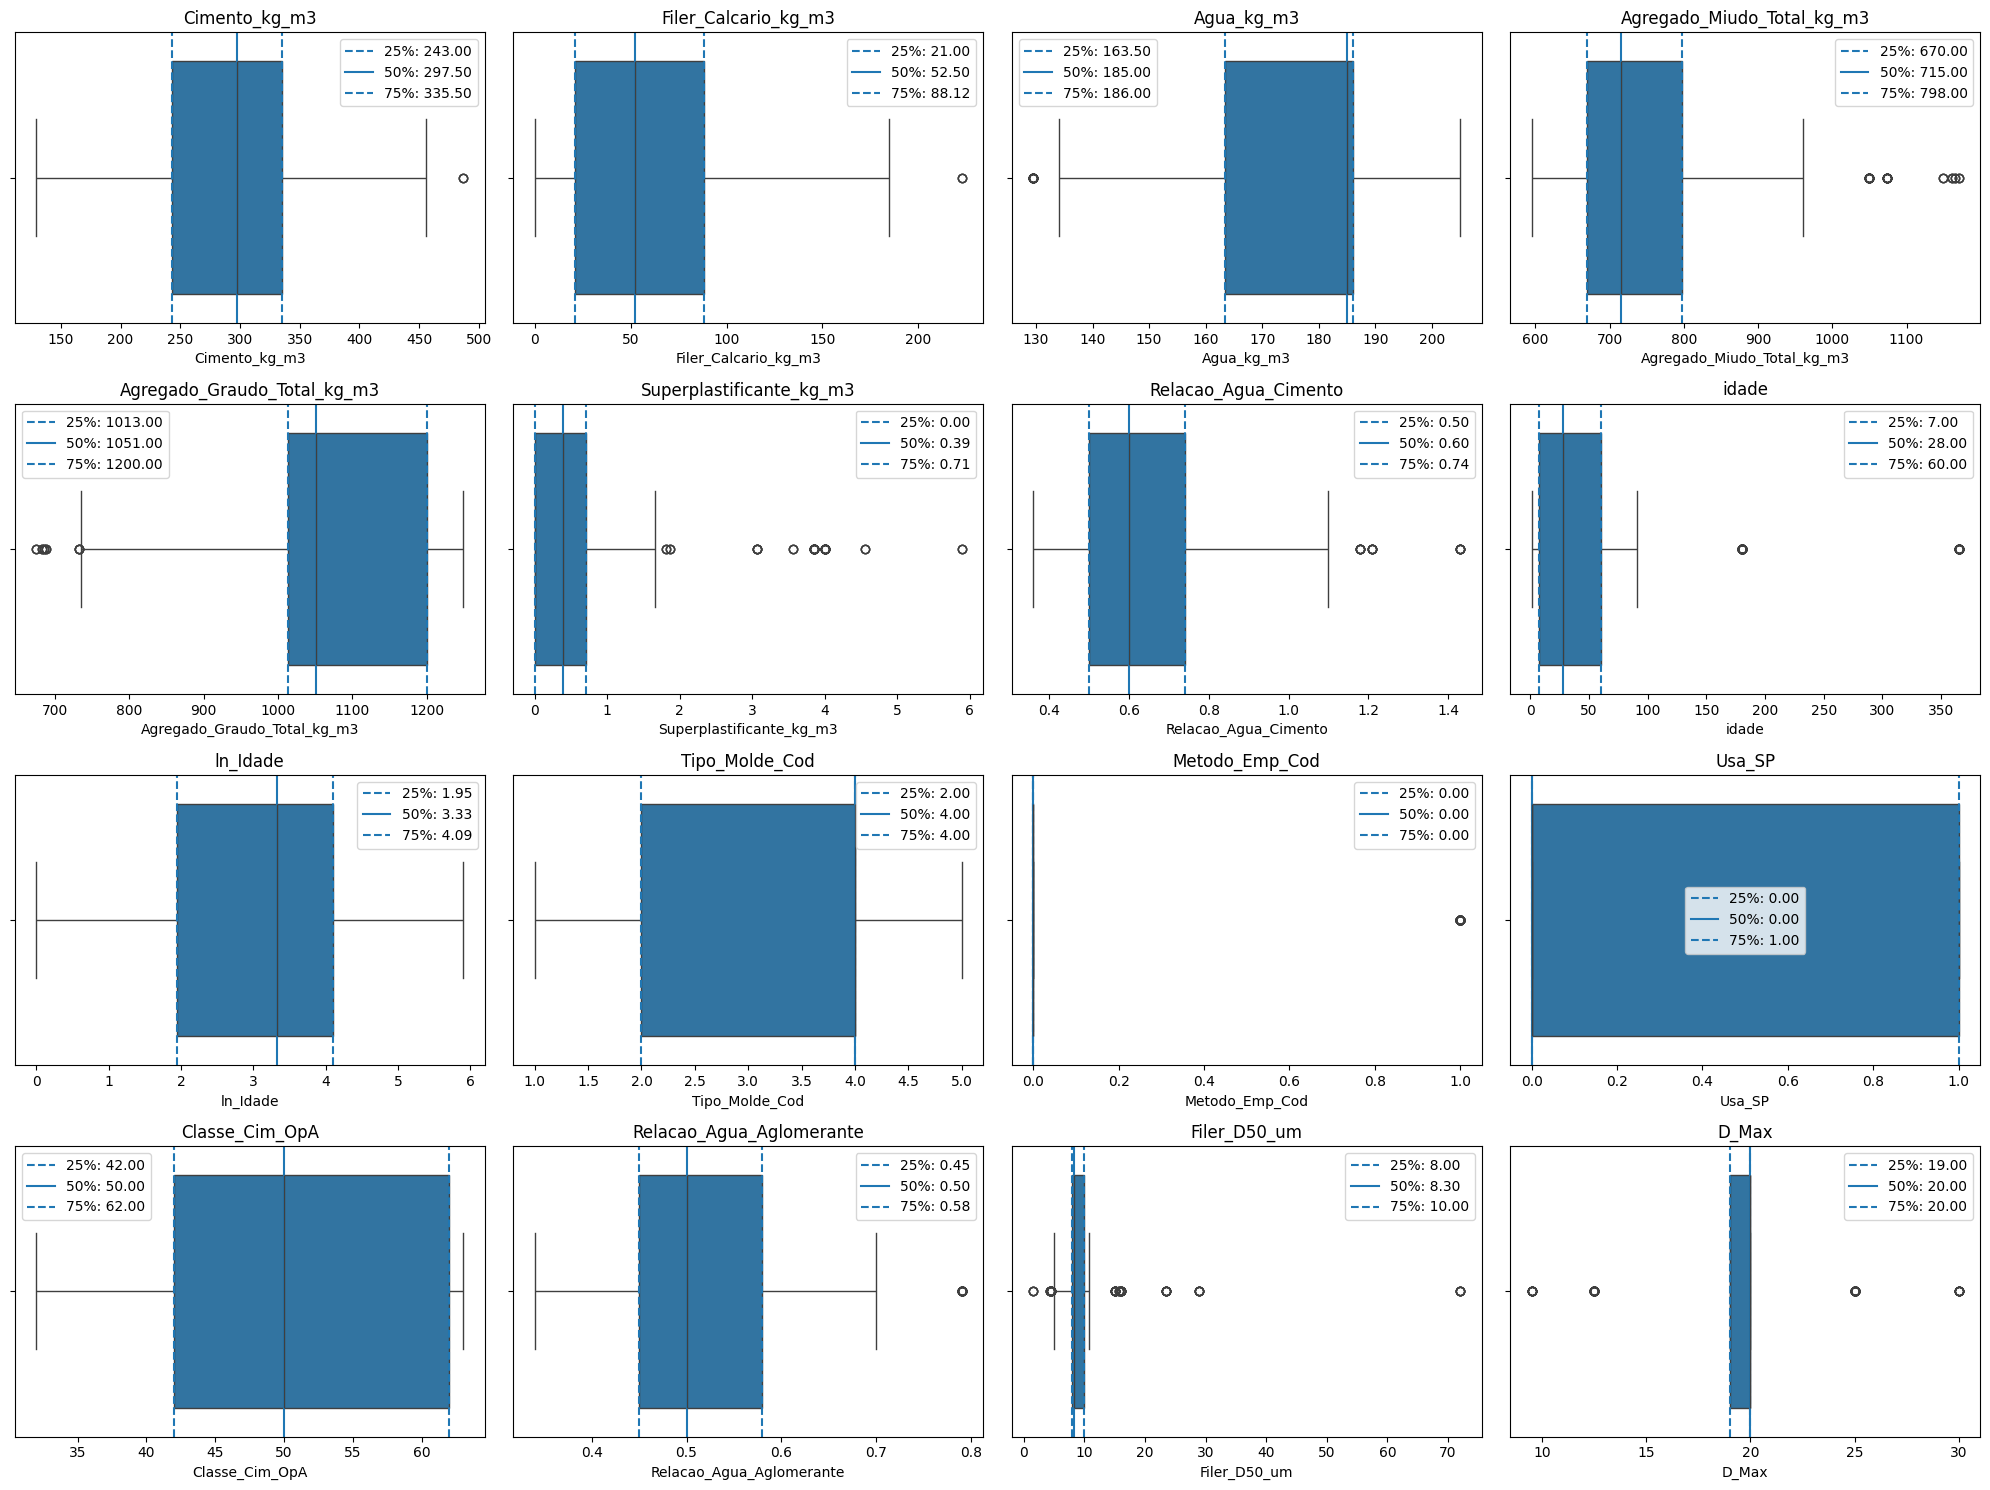

In [250]:
figure, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))

for i, column in enumerate(columns):
    if i == len(columns) - 1:
        continue
    ax = axes[i // 4, i % 4]
    data = df_resistencia[column]

    ax.set_title(column)
    sns.boxplot(x=data, ax=ax)
    
    stats = data.describe()

    # Linhas de referência
    ax.axvline(stats['25%'], linestyle='--', label=f"25%: {stats['25%']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"50%: {stats['50%']:.2f}")
    ax.axvline(stats['75%'], linestyle='--', label=f"75%: {stats['75%']:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

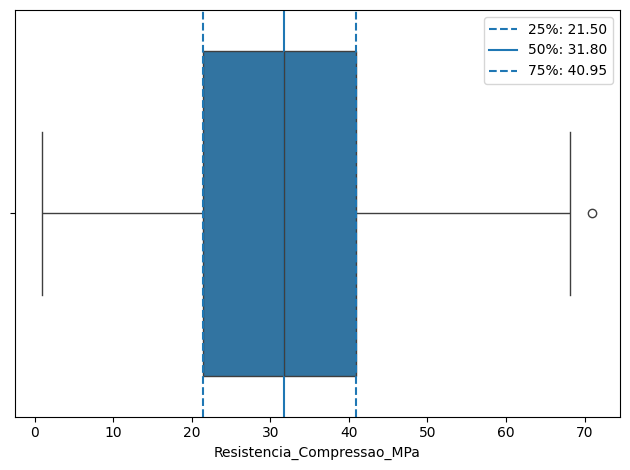

In [251]:
sns.boxplot(x=df_resistencia['Resistencia_Compressao_MPa'])
stats = df_resistencia['Resistencia_Compressao_MPa'].describe()
plt.axvline(stats['25%'], linestyle='--', label=f"25%: {stats['25%']:.2f}")
plt.axvline(stats['50%'], linestyle='-', label=f"50%: {stats['50%']:.2f}")
plt.axvline(stats['75%'], linestyle='--', label=f"75%: {stats['75%']:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

In [252]:
# Removendo coluna 'idade' de forma efetiva
df_resistencia.drop(columns=['idade'], inplace=True)

In [253]:
# Densidades típicas estimadas (em kg/m³)
DENSIDADE_CIMENTO = 3150
DENSIDADE_AGUA = 1000
DENSIDADE_FILER = 2700
DENSIDADE_AREIA = 2650  # Agregado miúdo
DENSIDADE_BRITA = 2700  # Agregado graúdo
DENSIDADE_SP = 1100     # Superplastificante

In [254]:
# Calculando o volume de cada componente (em m³ / m³ de concreto)
EPS = np.finfo(float).eps  # Pequeno valor para evitar divisão por zero
df_resistencia['vol_cimento'] = pd.to_numeric(df_resistencia['Cimento_kg_m3'], errors='coerce') / DENSIDADE_CIMENTO
df_resistencia['vol_agua'] = pd.to_numeric(df_resistencia['Agua_kg_m3'], errors='coerce') / DENSIDADE_AGUA
df_resistencia['vol_filer'] = pd.to_numeric(df_resistencia['Filer_Calcario_kg_m3'], errors='coerce') / DENSIDADE_FILER
df_resistencia['vol_areia'] = pd.to_numeric(df_resistencia['Agregado_Miudo_Total_kg_m3'], errors='coerce') / DENSIDADE_AREIA
df_resistencia['vol_brita'] = pd.to_numeric(df_resistencia['Agregado_Graudo_Total_kg_m3'], errors='coerce') / DENSIDADE_BRITA
df_resistencia['vol_sp'] = pd.to_numeric(df_resistencia['Superplastificante_kg_m3'], errors='coerce') / DENSIDADE_SP

# Somando o volume de todos os materiais inseridos
df_resistencia['volume_materiais'] = (
    df_resistencia['vol_cimento'] + 
    df_resistencia['vol_agua'] + 
    df_resistencia['vol_filer'] + 
    df_resistencia['vol_areia'] + 
    df_resistencia['vol_brita'] + 
    df_resistencia['vol_sp']
)

# O que falta para chegar a 1.0 m³ é o ar! 
# (Usamos clip para evitar números negativos minúsculos causados por imprecisão das densidades teóricas)
df_resistencia['vol_ar_aprisionado'] = (1.0 - df_resistencia['volume_materiais']).clip(lower=0)

# Volume Total de Vazios Iniciais (Água + Ar)
# Essa é a feature que representa a Porosidade Volumétrica Inicial do concreto fresco.
# Quanto MAIOR esse número, MENOR tende a ser a resistência.
df_resistencia['porosidade_volumetrica_inicial'] = (
    df_resistencia['vol_agua'] + df_resistencia['vol_ar_aprisionado']
)

# Volume de Sólidos Totais
df_resistencia['vol_solidos_totais'] = (
    df_resistencia['vol_cimento'] + 
    df_resistencia['vol_filer'] + 
    df_resistencia['vol_areia'] + 
    df_resistencia['vol_brita']
)

# Índice de Vazios (Vazios / Sólidos)
df_resistencia['indice_vazios'] = df_resistencia['porosidade_volumetrica_inicial'] / df_resistencia['vol_solidos_totais'].clip(lower=EPS)

# Concentração Volumétrica de Agregados
df_resistencia['concentracao_agregados'] = (
    df_resistencia['vol_areia'] + df_resistencia['vol_brita']
) / 1.0  # Em relação ao volume total de 1 m³

# Relação Agregado / Cimento
df_resistencia['agregado_cimento'] = (
    df_resistencia['Agregado_Graudo_Total_kg_m3'] +
    df_resistencia['Agregado_Miudo_Total_kg_m3']
) / df_resistencia['Cimento_kg_m3'].clip(lower=EPS)

# Proporção de pasta (cimento + água) em relação ao agregado total
df_resistencia['pasta_agregado'] = (
    df_resistencia['Cimento_kg_m3'] +
    df_resistencia['Agua_kg_m3']
) / (
    (df_resistencia['Agregado_Graudo_Total_kg_m3'] + df_resistencia['Agregado_Miudo_Total_kg_m3']).clip(lower=EPS)
)

# Proporção de finos (fíler) em relação ao cimento
df_resistencia['finos_total'] = df_resistencia['Filer_Calcario_kg_m3'] / df_resistencia['Cimento_kg_m3'].clip(lower=EPS)

# Volume total da pasta (cimento + água + fíler)
df_resistencia['volume_pasta'] = (
    df_resistencia['Agua_kg_m3'] +
    df_resistencia['Cimento_kg_m3'] +
    df_resistencia['Filer_Calcario_kg_m3']
)

# Fração de Graúdo (Agregado graúdo / Agregado total)
df_resistencia['frac_graudo'] = df_resistencia['Agregado_Graudo_Total_kg_m3'] / (
    (df_resistencia['Agregado_Graudo_Total_kg_m3'] + df_resistencia['Agregado_Miudo_Total_kg_m3']).clip(lower=EPS)
)

# Quantidade total de aglomerante (cimento + fíler)
df_resistencia['aglomerante_total'] = (
    df_resistencia['Cimento_kg_m3'] +
    df_resistencia['Filer_Calcario_kg_m3']
)

# Tratamento não-linear do tempo (MUITO importante para concreto)
df_resistencia['inv_idade'] = 1 / (pd.to_numeric(df_resistencia['ln_Idade'], errors='coerce') + EPS)  # Evita divisão por zero

# Taxas de Adição de Aditivo (% sobre a massa de cimento)
df_resistencia['taxa_sp_cimento'] = df_resistencia['Superplastificante_kg_m3'] / df_resistencia['Cimento_kg_m3'].clip(lower=EPS)

# Taxa de Adição de Aditivo (% sobre a massa total de aglomerante)
df_resistencia['taxa_sp_aglomerante'] = df_resistencia['Superplastificante_kg_m3'] / df_resistencia['aglomerante_total'].clip(lower=EPS)

# Água sobre Sólidos Totais
solidos_totais = (
    pd.to_numeric(df_resistencia['Cimento_kg_m3'], errors='coerce') + 
    pd.to_numeric(df_resistencia['Filer_Calcario_kg_m3'], errors='coerce') + 
    pd.to_numeric(df_resistencia['Agregado_Miudo_Total_kg_m3'], errors='coerce') + 
    pd.to_numeric(df_resistencia['Agregado_Graudo_Total_kg_m3'], errors='coerce')
)
df_resistencia['agua_solidos'] = df_resistencia['Agua_kg_m3'] / solidos_totais.clip(lower=EPS)

# Se D_Max já esta em mm, multiplicamos por 1000 para ficar na mesma unidade do Filer_D50_um
df_resistencia['range_granulometrico'] = (
    (df_resistencia['D_Max'] * 1000) / (df_resistencia['Filer_D50_um'] + EPS)
)

# Interação Termodinâmica (Idade x Água/Cimento)
df_resistencia['idade_ac'] = pd.to_numeric(df_resistencia['ln_Idade'], errors='coerce') / df_resistencia['Relacao_Agua_Cimento'].clip(lower=EPS)

# Parâmetro de Féret (Usando os volumes que calculamos anteriormente)
# Essa variável tem uma relação quase linear com a resistência!
df_resistencia['parametro_feret'] = (
    df_resistencia['vol_cimento'] / (df_resistencia['vol_cimento'] + df_resistencia['vol_agua'] + df_resistencia['vol_ar_aprisionado']).clip(lower=EPS)
) ** 2

# Interação Termodinâmica com Féret (Idade x Água/Cimento x Féret)
df_resistencia['idade_ac_feret'] = df_resistencia['idade_ac'] * df_resistencia['parametro_feret']

# Fator Água / Pó (Volume de Água sobre Volume de Cimento + Fíler)
# Captura a densidade da matriz da pasta
df_resistencia['vol_po_total'] = df_resistencia['vol_cimento'] + df_resistencia['vol_filer']
df_resistencia['fator_agua_po'] = df_resistencia['vol_agua'] / df_resistencia['vol_po_total'].clip(lower=EPS)

# Taxa de Inertes na Matriz Fina
# Mostra qual a porcentagem de todo o "pó" que NÃO tem poder de cimentação
df_resistencia['taxa_filer_inerte'] = df_resistencia['Filer_Calcario_kg_m3'] / (df_resistencia['Cimento_kg_m3'] + df_resistencia['Filer_Calcario_kg_m3']).clip(lower=EPS)

# Relação de Superfície Específica (Pasta vs. Areia)
# A areia "rouba" a pasta. Muita areia exige muita pasta.
df_resistencia['pasta_areia_volumetrica'] = (
    (df_resistencia['vol_cimento'] + df_resistencia['vol_agua'] + df_resistencia['vol_filer']) / (df_resistencia['vol_areia'] + EPS)
)

In [263]:
df_resistencia.corr(method='spearman')['Resistencia_Compressao_MPa'].abs().sort_values(ascending=False)

,Resistencia_Compressao_MPa
Resistencia_Compressao_MPa,1.000000
idade_ac_feret,0.885065
idade_ac,0.818905
Relacao_Agua_Cimento,0.612689
parametro_feret,0.608895
Cimento_kg_m3,0.572486
vol_cimento,0.572486
ln_Idade,0.557420
inv_idade,0.557420
agregado_cimento,0.537213


In [255]:
# Defina sua variável alvo (substitua pelo nome correto da sua coluna)
ALVO = 'Resistencia_Compressao_MPa' 

# 1. Calcula a matriz de correlação de Spearman
corr_matrix = df_resistencia.corr(method='spearman').abs()

# 2. Pega a correlação de todas as features com o Alvo
corr_com_alvo = corr_matrix[ALVO].drop(ALVO)

# 3. Identifica pares altamente correlacionados (limite de 0.90)
limite_colinearidade = 0.90
features_para_remover = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        
        # Ignora a comparação se uma delas for o Alvo
        if col_i == ALVO or col_j == ALVO:
            continue
            
        # Se a correlação entre as duas features for maior que o limite
        if corr_matrix.iloc[i, j] > limite_colinearidade:
            # Comparamos quem explica menos o alvo e colocamos na lista de corte
            if corr_com_alvo[col_i] > corr_com_alvo[col_j]:
                features_para_remover.add(col_j)
            else:
                features_para_remover.add(col_i)

print(f"Features removidas por colinearidade: {features_para_remover}")
df_filtrado = df_resistencia.drop(columns=features_para_remover)

Features removidas por colinearidade: {'vol_cimento', 'fator_agua_po', 'idade_ac', 'vol_areia', 'inv_idade', 'pasta_agregado', 'Filer_Calcario_kg_m3', 'taxa_filer_inerte', 'taxa_sp_cimento', 'vol_brita', 'vol_sp', 'indice_vazios', 'frac_graudo', 'vol_agua', 'Usa_SP', 'taxa_sp_aglomerante', 'vol_solidos_totais', 'vol_filer', 'agregado_cimento', 'volume_materiais', 'pasta_areia_volumetrica', 'Agua_kg_m3', 'vol_po_total', 'Agregado_Miudo_Total_kg_m3'}


In [256]:
df_filtrado.corr(method='spearman')['Resistencia_Compressao_MPa'].abs().sort_values(ascending=False)

,Resistencia_Compressao_MPa
Resistencia_Compressao_MPa,1.000000
idade_ac_feret,0.885065
Relacao_Agua_Cimento,0.612689
parametro_feret,0.608895
Cimento_kg_m3,0.572486
ln_Idade,0.557420
Relacao_Agua_Aglomerante,0.505456
finos_total,0.447780
aglomerante_total,0.417404
agua_solidos,0.328853


In [258]:
# 1. Preparando os dados
X = df_filtrado.drop(columns=[ALVO]).copy()
y = df_filtrado[ALVO]

nome_modelo = "HGBR"

# 2. Dicionário com os seus competidores (O CatBoost precisa do verbose=False para não poluir a tela)
modelos = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=False, thread_count=-1),
    "HGBR": GradientBoostingRegressor(random_state=42) # Usado no lugar do HGBR
}

if nome_modelo == "HGBR":
    X.fillna(X.mean(), inplace=True)  # Preenche valores faltantes com a média (HGBR não lida bem com NaNs)

# Dicionário para guardar os resultados de cada modelo
resultados_selecao = {}

# 3. O Loop de Automação
estimador = modelos[nome_modelo]
print(f"⏳ Rodando RFECV para o modelo: {nome_modelo}...")

seletor_rfecv = RFECV(
    estimator=estimador, 
    step=1, 
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    min_features_to_select=5,
    n_jobs=-1
)

# Treina o seletor
seletor_rfecv.fit(X, y)

# Salva as features que sobreviveram para este modelo
features_sobreviventes = list(X.columns[seletor_rfecv.support_])

resultados_selecao[nome_modelo] = {
    "Qtd_Otimizada": seletor_rfecv.n_features_,
    "Features_Selecionadas": features_sobreviventes
}

print(f"✅ {nome_modelo} finalizado! Elegeu {seletor_rfecv.n_features_} features.\n")
df_final = df_filtrado[resultados_selecao[nome_modelo]["Features_Selecionadas"] + [ALVO]]


⏳ Rodando RFECV para o modelo: HGBR...


✅ HGBR finalizado! Elegeu 20 features.



In [259]:
columns = df_final.columns

outliers_idx = {}
for column in columns:
    if column == 'bins' or column == 'Resistencia_Compressao_MPa':
        continue
    data = df_final[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()

for column, idx in sorted(outliers_idx.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{column}: {len(idx)} outliers")

D_Max: 109 outliers
Metodo_Emp_Cod: 83 outliers
Filer_D50_um: 75 outliers
Superplastificante_kg_m3: 70 outliers
vol_ar_aprisionado: 65 outliers
range_granulometrico: 60 outliers
aglomerante_total: 47 outliers
finos_total: 38 outliers
Relacao_Agua_Aglomerante: 36 outliers
agua_solidos: 25 outliers
idade_ac_feret: 22 outliers
Relacao_Agua_Cimento: 21 outliers
Agregado_Graudo_Total_kg_m3: 17 outliers
porosidade_volumetrica_inicial: 15 outliers
Cimento_kg_m3: 3 outliers
ln_Idade: 0 outliers
Tipo_Molde_Cod: 0 outliers
Classe_Cim_OpA: 0 outliers
concentracao_agregados: 0 outliers
parametro_feret: 0 outliers


In [260]:
df_final['bins'] = pd.qcut(df_final['Resistencia_Compressao_MPa'], q=10, duplicates='drop')

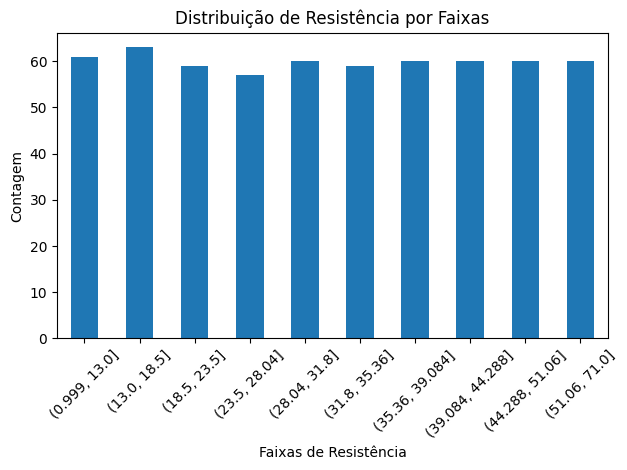

In [261]:
df_final['bins'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuição de Resistência por Faixas')
plt.xlabel('Faixas de Resistência')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [262]:
df_final.to_pickle(os.path.join(base_dir, f'df_resistencia_{nome_modelo}.pkl'))